In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
import seaborn as sns

In [16]:
df = pd.read_csv('../results.csv')
print(df.shape)
df.head(3)

(11312280, 16)


,delta1,delta2,eps,coupling_type,x0,y0,x1,y1,x2,y2,L,A,P,s01,s02,s12
0,-0.5,-0.5,0.01,0,1.779260,-1.899390,1.67815,0.581101,-0.325003,-2.40015,0.503756,0.178762,0.389772,0.500810,0.500799,0.000012
1,-0.5,-0.5,0.01,0,-0.244507,-0.997748,-2.14280,0.905331,-2.661530,1.33199,0.699751,0.223964,0.428436,0.500822,0.500834,0.000012
2,-0.5,-0.5,0.01,0,2.631320,-2.995330,2.95327,0.704889,0.669919,-2.95760,1.570350,0.408159,0.549283,0.500965,0.500944,0.000020


In [17]:
COUPLING_NAMES = ['Inertial', 'InertialNorm', 'Dissipative', 'DissipativeNorm']
epsilons = sorted(df['eps'].unique())
print('epsilons:', epsilons)
print('coupling types:', df['coupling_type'].unique())
print('runs per point:', df.groupby(['delta1','delta2','eps','coupling_type']).size().unique())

epsilons: [np.float64(0.01), np.float64(0.03), np.float64(0.05), np.float64(0.07), np.float64(0.1), np.float64(0.15), np.float64(0.2)]
coupling types: [0 1 2 3]
runs per point: [10]


In [18]:
eps_val = epsilons[2]  # epsilons = [0.01, 0.03, 0.05, 0.07, 0.1, 0.15, 0.2] -> [2] = 0.05

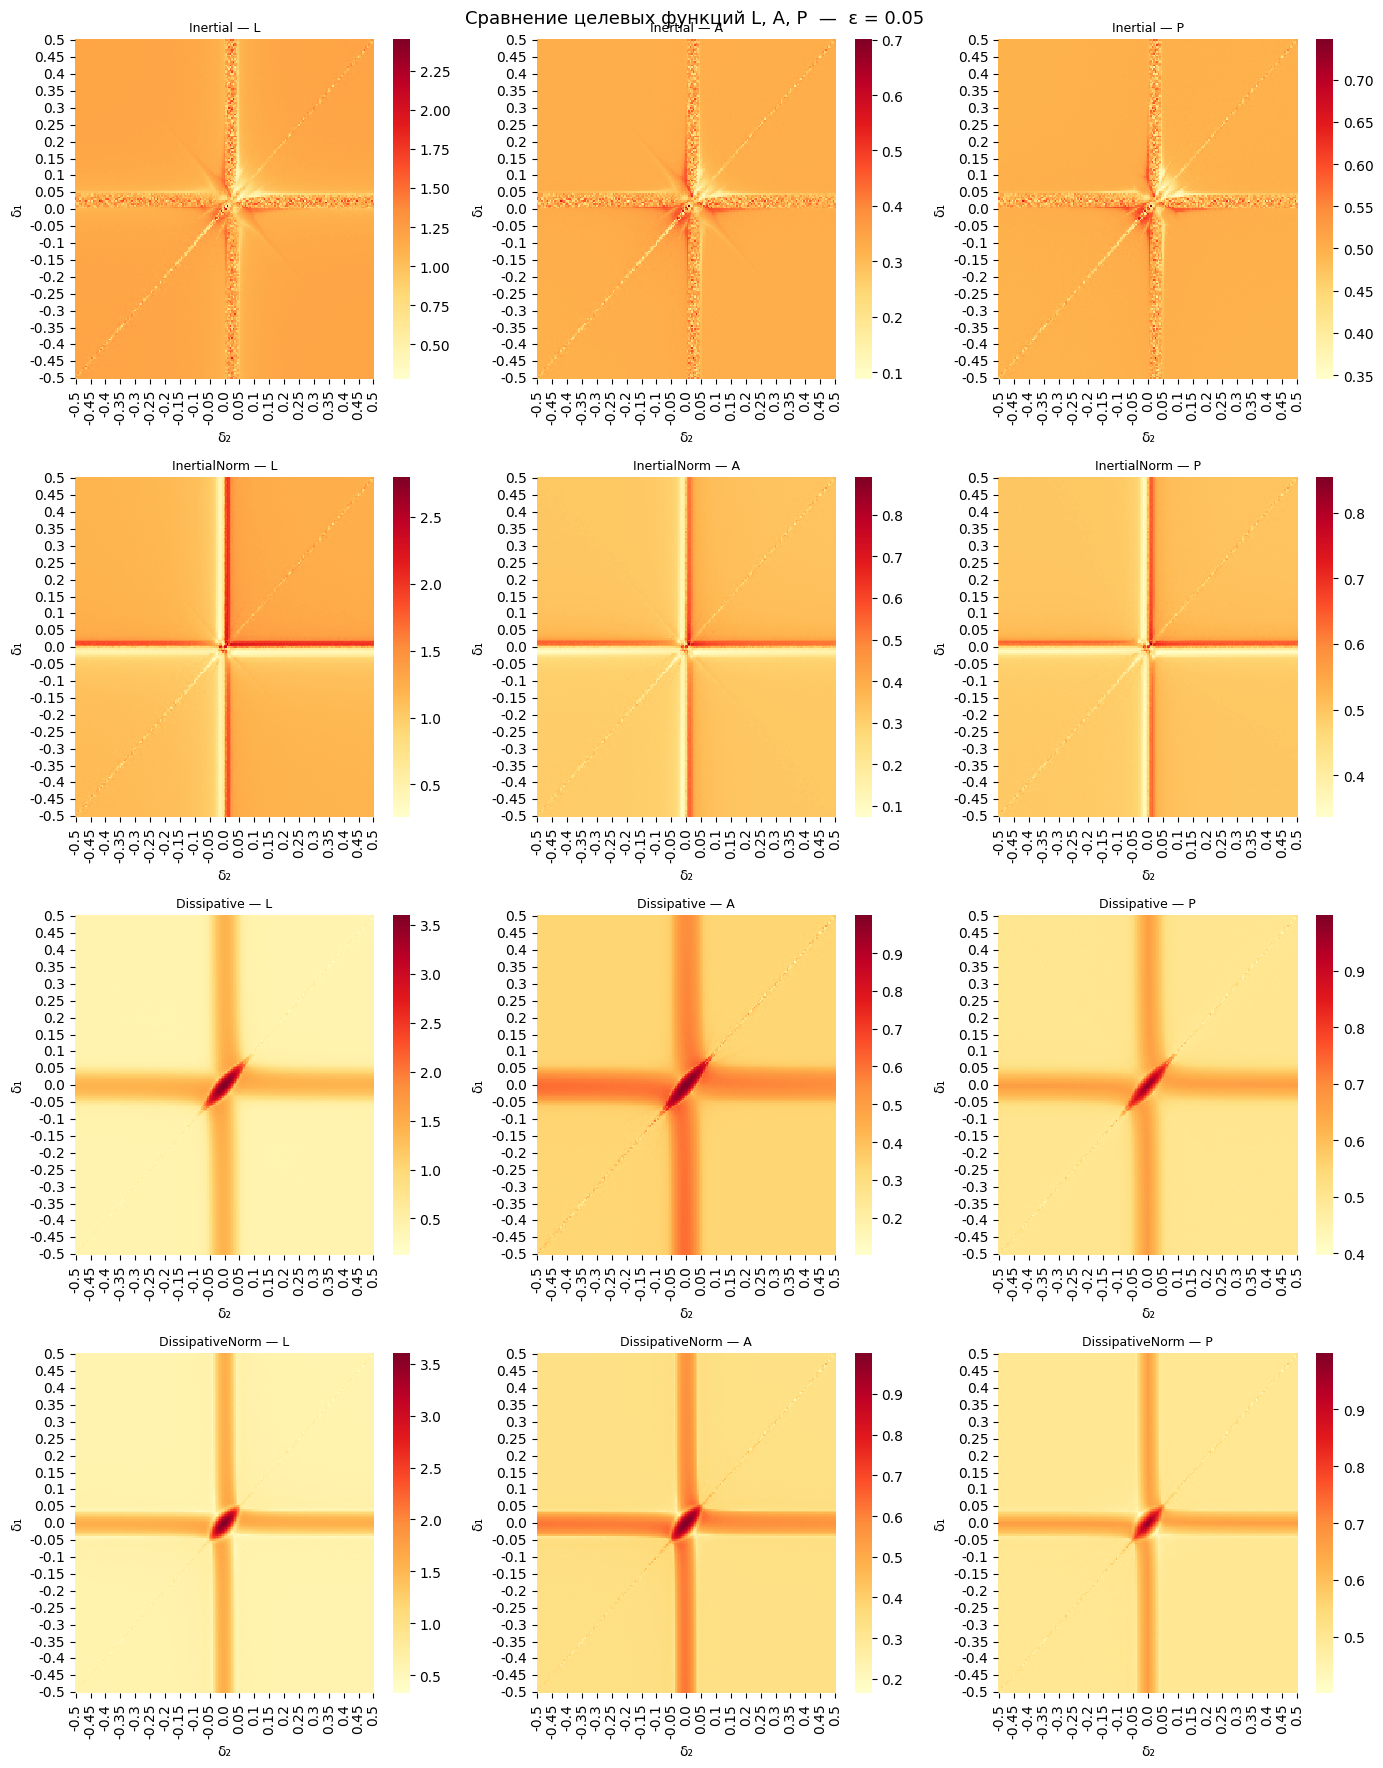

In [19]:
def plot_goal_maps(eps_val):
    sub = df[df['eps'] == eps_val]
    agg = sub.groupby(['delta1', 'delta2', 'coupling_type']).agg(
        L=('L', 'mean'),
        A=('A', 'mean'),
        P=('P', 'mean'),
    ).reset_index()

    fig, axes = plt.subplots(4, 3, figsize=(14, 18))
    fig.suptitle(f'Сравнение целевых функций L, A, P  —  ε = {eps_val}', fontsize=13)

    for ct in range(4):
        data = agg[agg['coupling_type'] == ct]
        for col, col_name in enumerate(['L', 'A', 'P']):
            pivot = data.pivot(index='delta1', columns='delta2', values=col_name).iloc[::-1]
            sns.heatmap(pivot, cmap='YlOrRd', ax=axes[ct, col],
                        xticklabels=10, yticklabels=10)
            axes[ct, col].set_title(f'{COUPLING_NAMES[ct]} — {col_name}', fontsize=9)
            axes[ct, col].set_xlabel('δ₂'); axes[ct, col].set_ylabel('δ₁')

    plt.tight_layout()
    plt.show()

plot_goal_maps(eps_val)

## Сравнение целевых функций

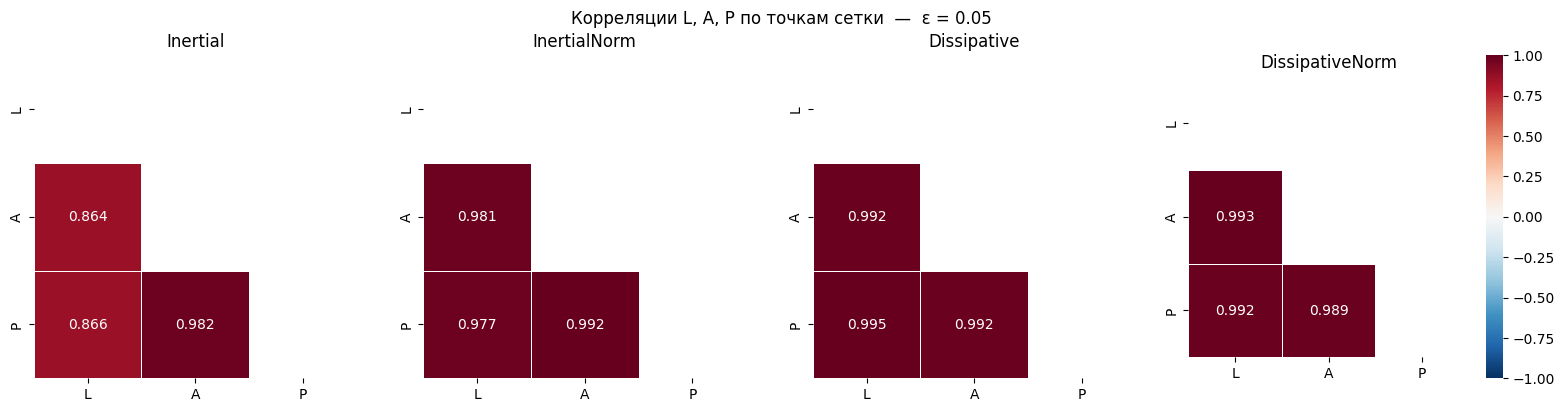

In [20]:
import seaborn as sns

def goal_correlations(eps_val):
    sub = df[df['eps'] == eps_val]
    agg = sub.groupby(['delta1', 'delta2', 'coupling_type'])[['L', 'A', 'P']].mean().reset_index()

    mask = np.triu(np.ones((3, 3), dtype=bool))

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    fig.suptitle(f'Корреляции L, A, P по точкам сетки  —  ε = {eps_val}', fontsize=12)

    for ct in range(4):
        corr = agg[agg['coupling_type'] == ct][['L', 'A', 'P']].corr()
        sns.heatmap(corr, mask=mask, annot=True, fmt='.3f',
                    vmin=-1, vmax=1, cmap='RdBu_r',
                    ax=axes[ct], square=True, linewidths=0.5,
                    cbar=(ct == 3))
        axes[ct].set_title(COUPLING_NAMES[ct])

    plt.tight_layout()
    plt.show()

goal_correlations(eps_val)

**Вывод.** A (когерентность через амплитуды) и P (через фазы) дают качественно схожую картину при диссипативной связи (ρ ≈ 0.90–0.92), но заметно расходятся при инерционной (ρ = 0.60). При инерционной связи выбор метрики влияет на результат — это нужно учитывать при постановке задачи оптимального воздействия.

L близка к A при диссипативной связи (ρ ≈ 1.00) и расходится при инерционной (ρ = 0.67) — потому что L считает только по x, A по x и y.

## Карта режимов синхронизации (доминирующий режим)

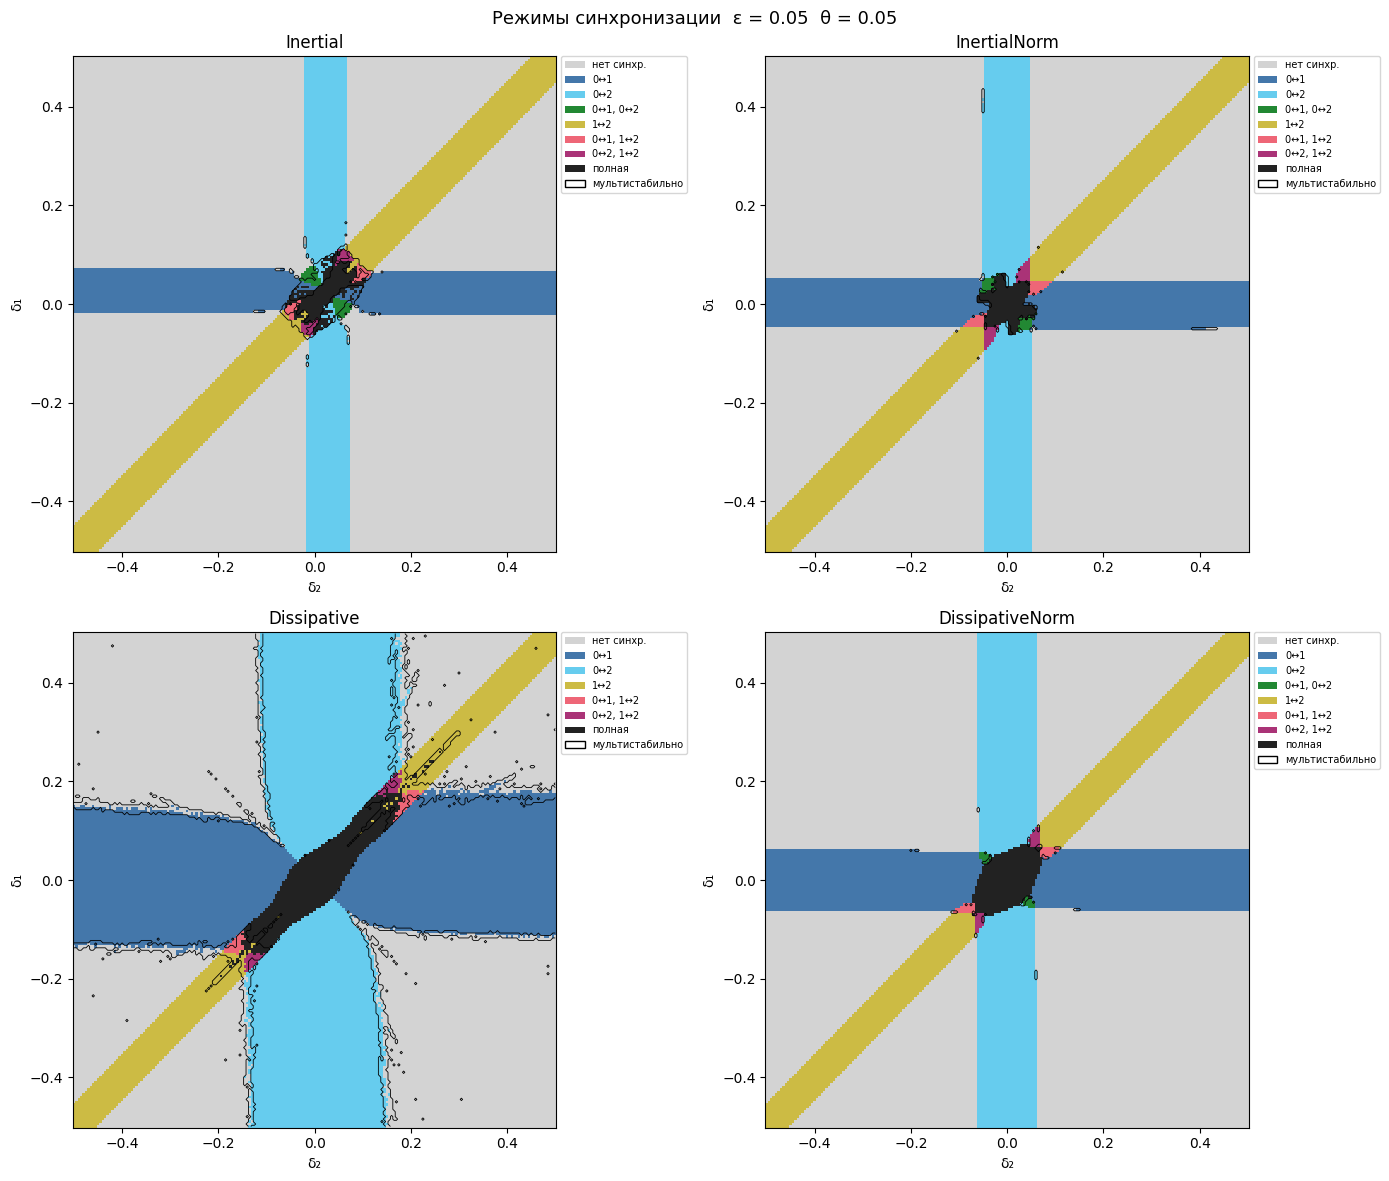

In [21]:
REGIME_LABELS = [
    'нет синхр.',    # 0
    '0↔1',           # 1
    '0↔2',           # 2
    '0↔1, 0↔2',     # 3
    '1↔2',           # 4
    '0↔1, 1↔2',     # 5
    '0↔2, 1↔2',     # 6
    'полная',        # 7
]
REGIME_COLORS = ['#d3d3d3','#4477aa','#66ccee','#228833','#ccbb44','#ee6677','#aa3377','#222222']

def sync_code(row, theta):
    return int(row['s01'] < theta) | (int(row['s02'] < theta) << 1) | (int(row['s12'] < theta) << 2)

def draw_borders(ax, pivot, linewidth=0.6, color='black'):
    # Обводим ГРАНИЦУ мультистабильных областей через contour, а не каждую ячейку
    # прямоугольником: на мелкой сетке (шаг 0.005) рамка Rectangle толще ячейки и
    # заливает её целиком, превращая обводку в сплошные чёрные квадраты.
    d1 = pivot.index.values      # delta1 -> y
    d2 = pivot.columns.values    # delta2 -> x
    Z = np.nan_to_num(pivot.values.astype(float), nan=0.0)
    ax.contour(d2, d1, Z, levels=[0.5], colors=color, linewidths=linewidth)

def plot_regime_maps(eps_val, theta=0.05):
    sub = df[df['eps'] == eps_val].copy()
    sub['code'] = sub.apply(lambda r: sync_code(r, theta), axis=1)
    
    agg = sub.groupby(['delta1', 'delta2', 'coupling_type']).agg(
        dominant_code=('code', lambda x: x.value_counts().idxmax()),
        multi_regime=('code', lambda x: x.nunique() > 1),
    ).reset_index()
    
    cmap = mcolors.ListedColormap(REGIME_COLORS)
    norm = mcolors.BoundaryNorm(np.arange(-0.5, 8.5), ncolors=8)
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    fig.suptitle(f'Режимы синхронизации  ε = {eps_val}  θ = {theta}', fontsize=13)
    
    for ct in range(4):
        ax = axes[ct // 2, ct % 2]
        data = agg[agg['coupling_type'] == ct]
        
        dom     = data.pivot(index='delta1', columns='delta2', values='dominant_code')
        mul_reg = data.pivot(index='delta1', columns='delta2', values='multi_regime')
        
        ax.pcolormesh(dom.columns, dom.index, dom.values, cmap=cmap, norm=norm, shading='auto')
        draw_borders(ax, mul_reg, linewidth=0.6, color='black')
        
        ax.set_title(COUPLING_NAMES[ct])
        ax.set_xlabel('δ₂'); ax.set_ylabel('δ₁')
        
        present = sorted(data['dominant_code'].unique())
        handles = [Patch(facecolor=REGIME_COLORS[c], label=REGIME_LABELS[c]) for c in present]
        handles.append(Patch(facecolor='white', edgecolor='black', label='мультистабильно'))
        ax.legend(handles=handles, loc='upper left', bbox_to_anchor=(1.01, 1), borderaxespad=0, fontsize=7)
    
    plt.tight_layout()
    plt.show()

plot_regime_maps(eps_val)

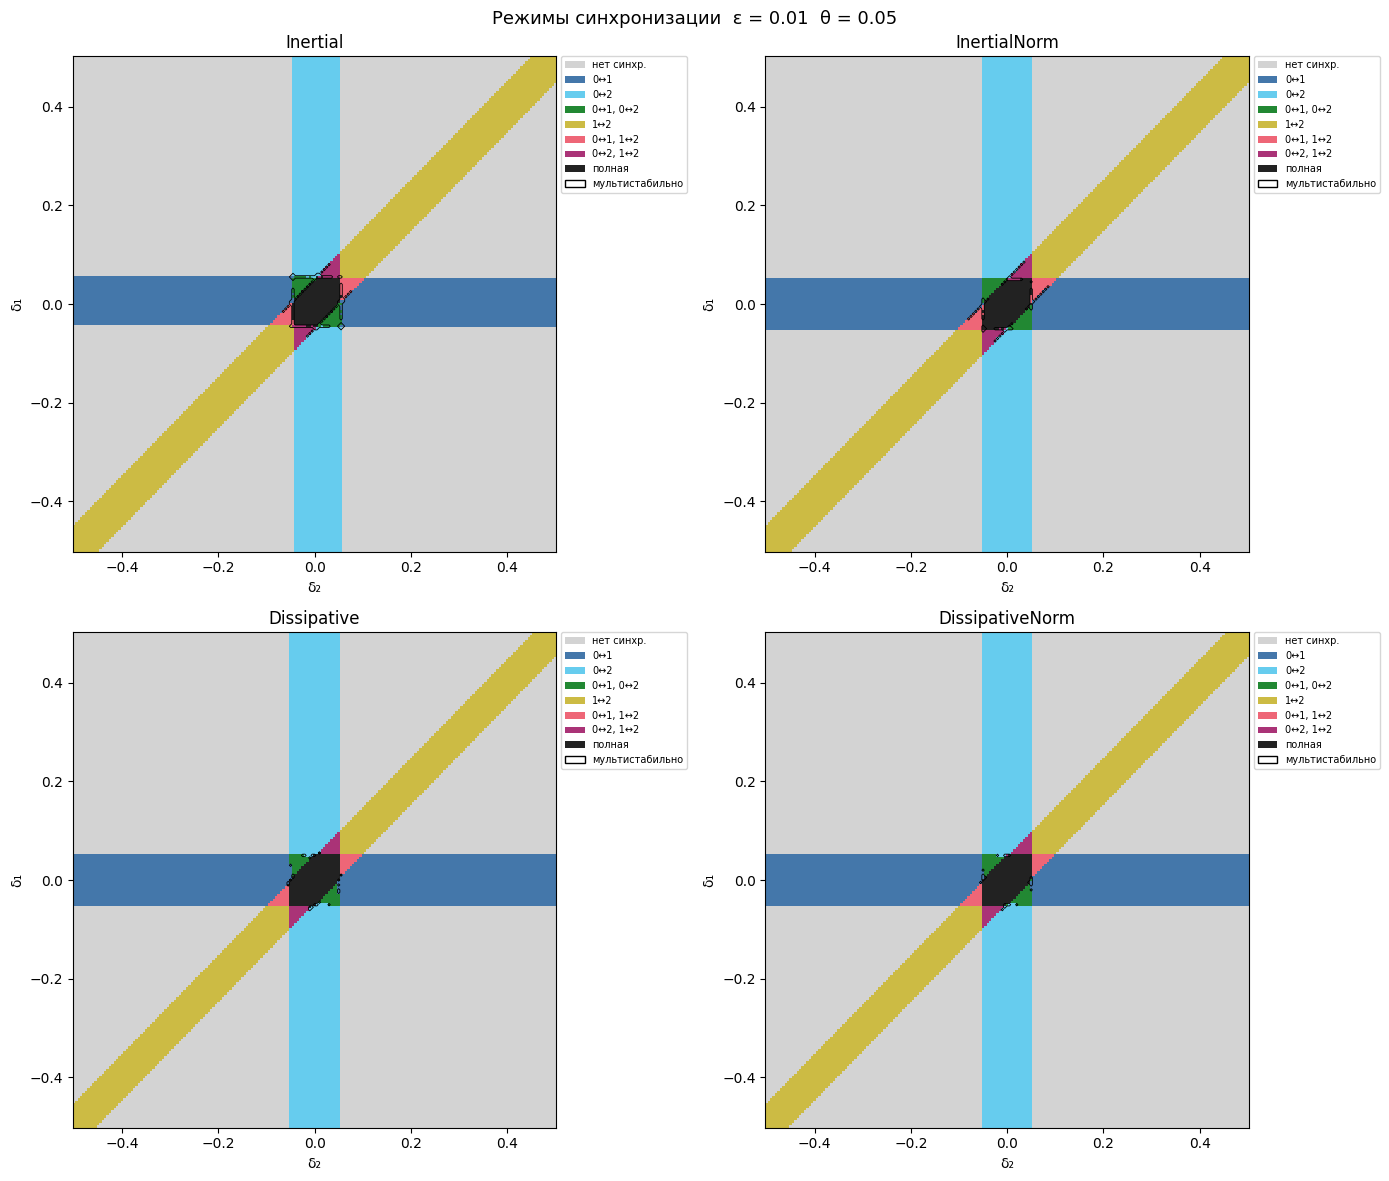

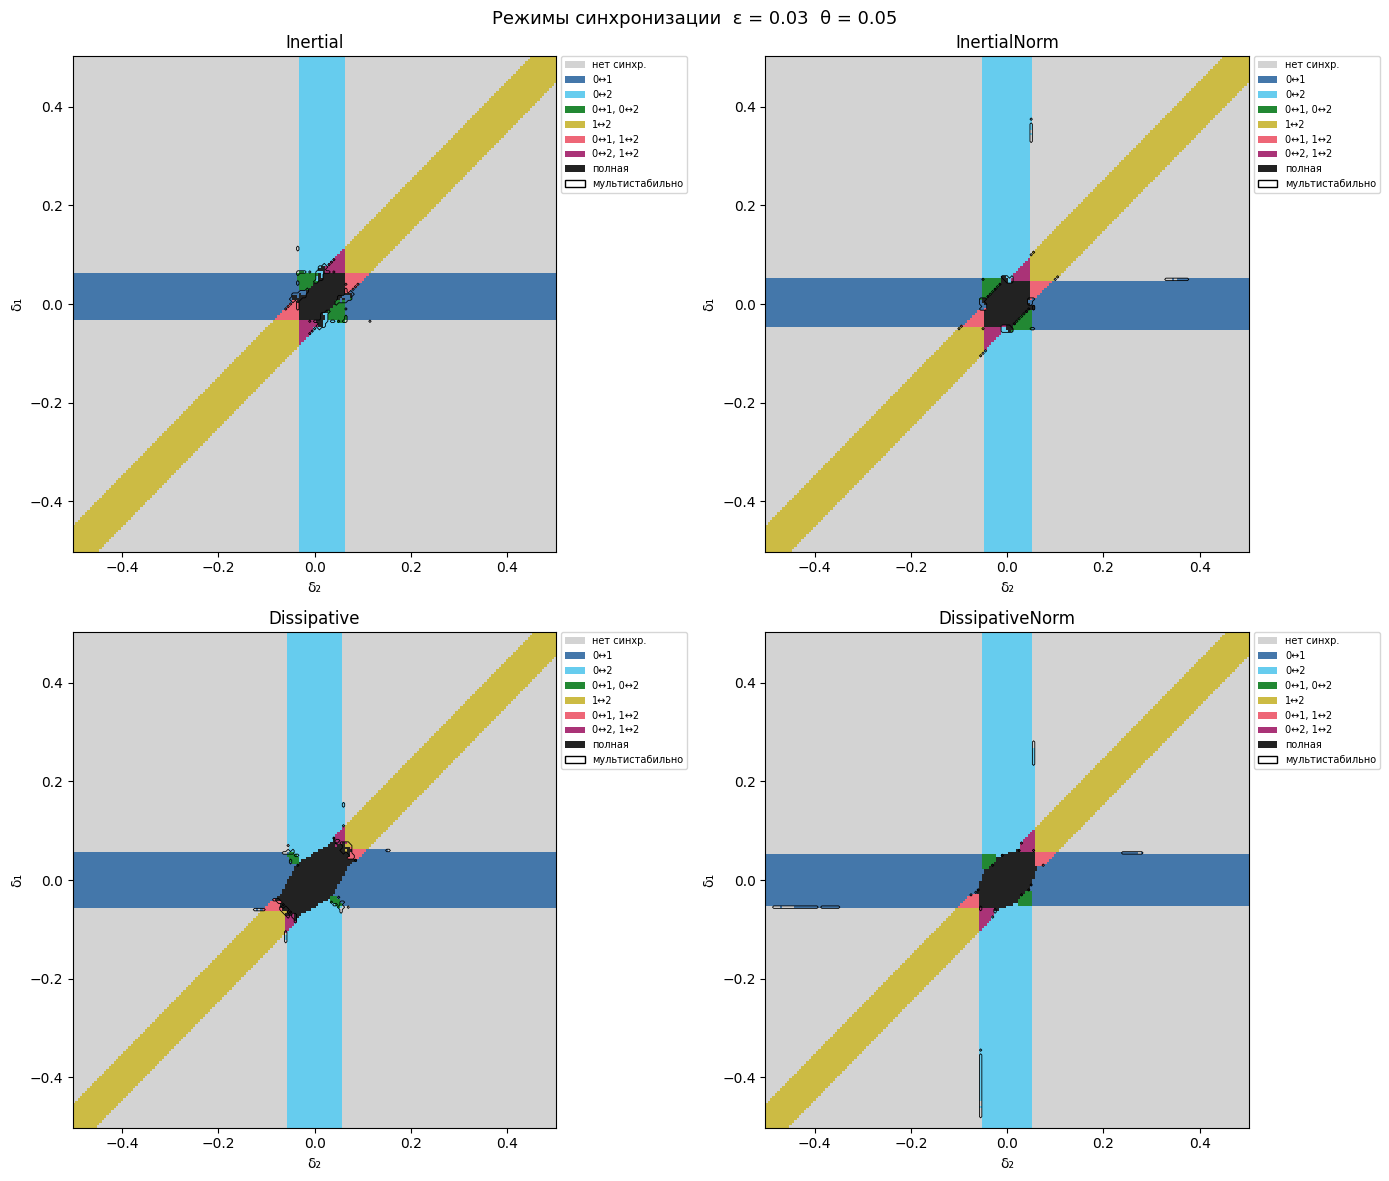

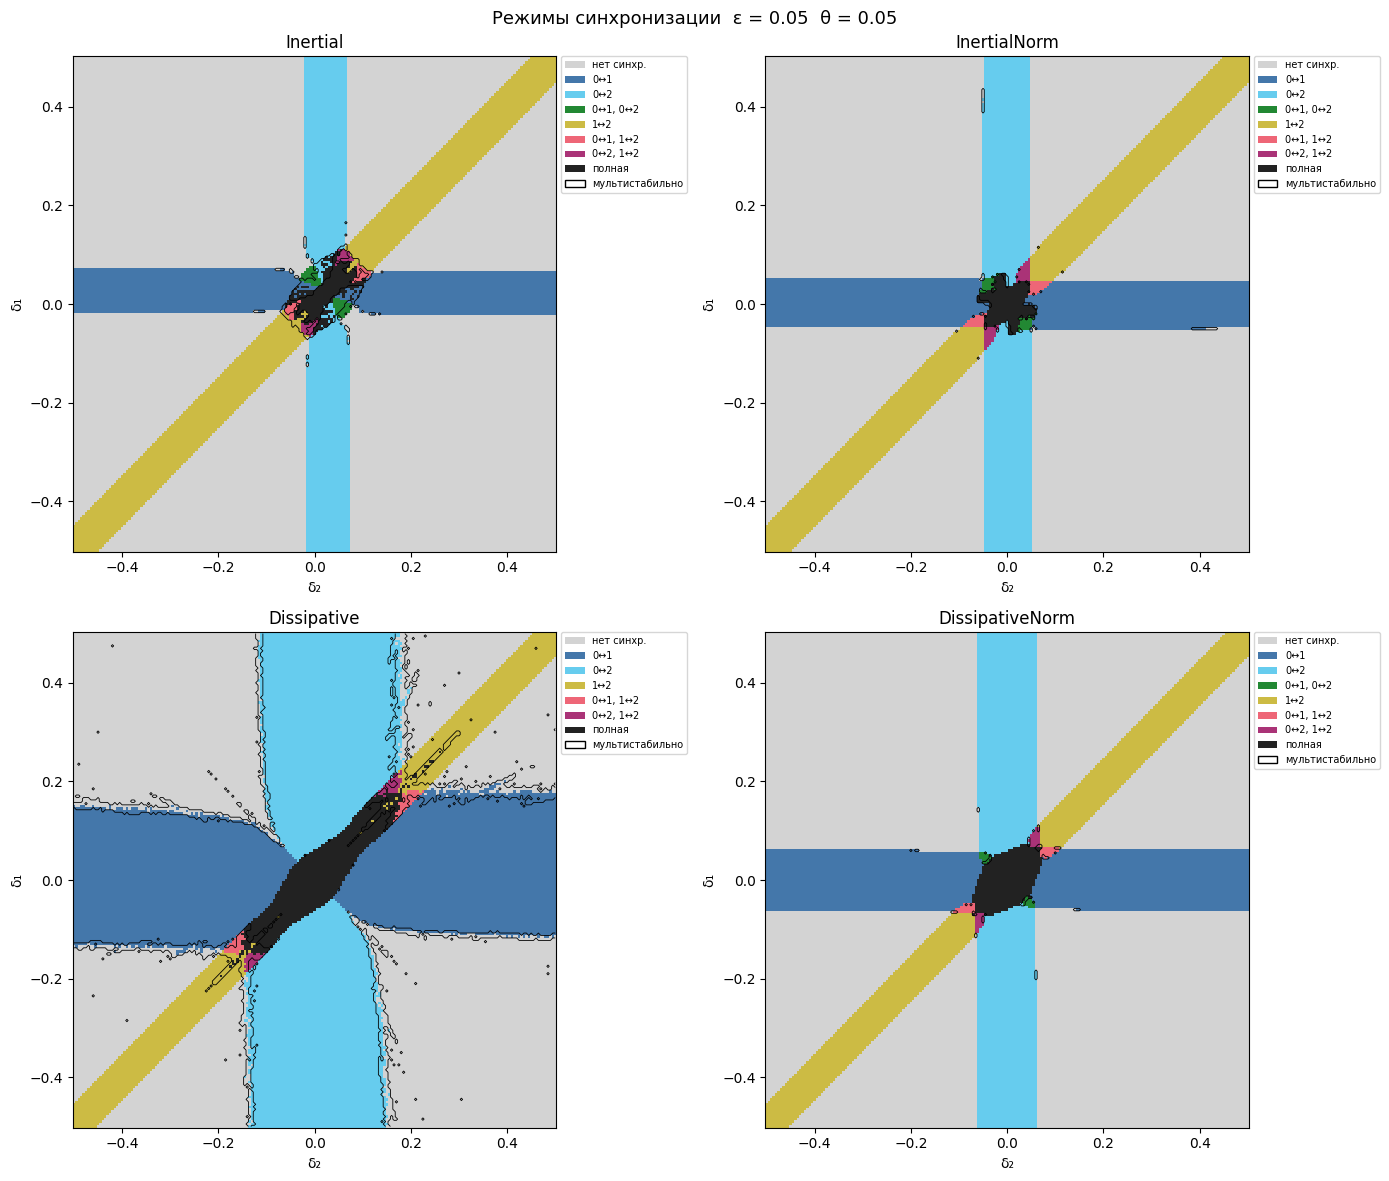

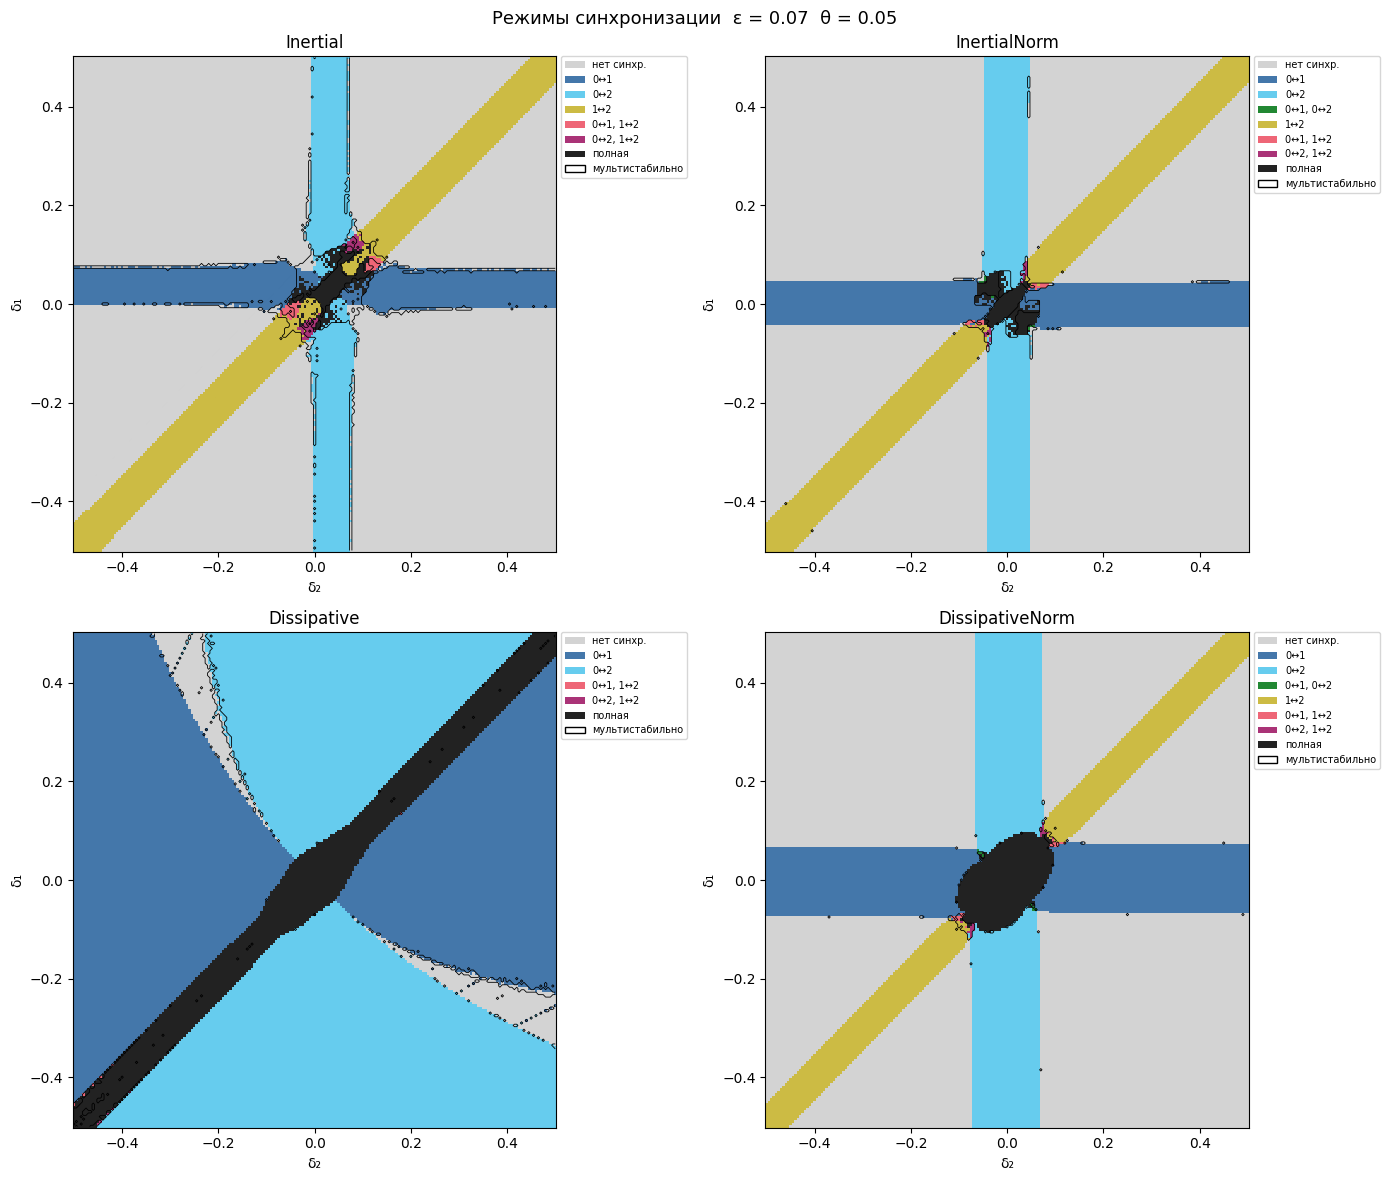

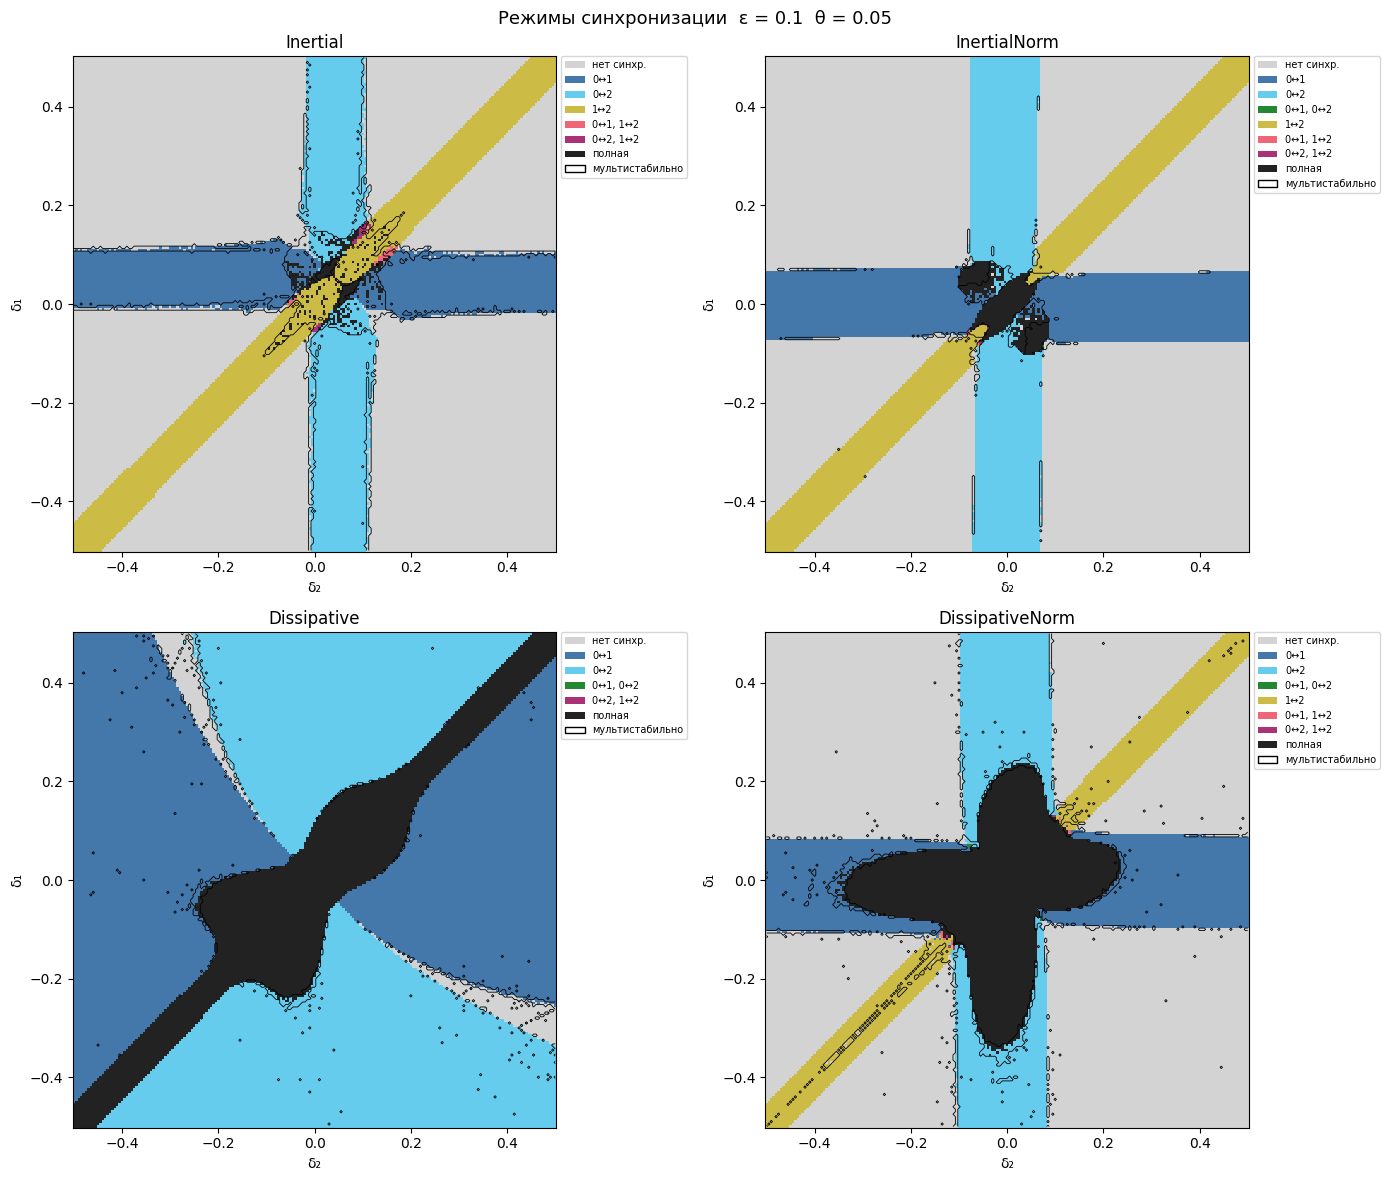

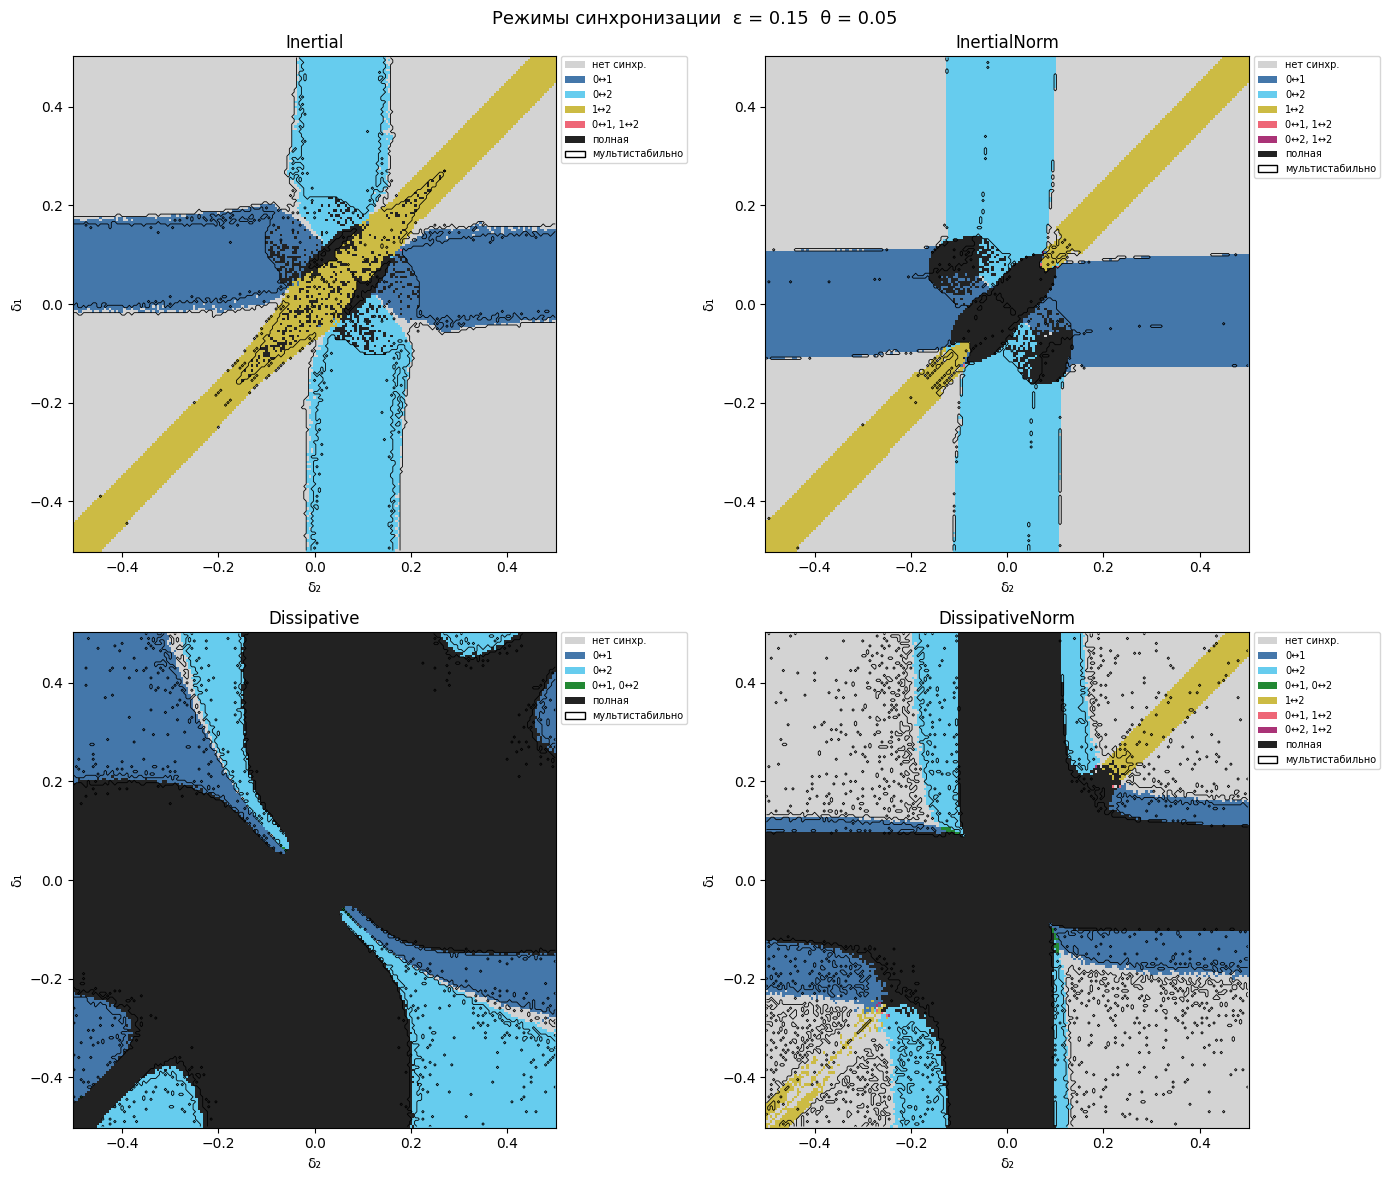

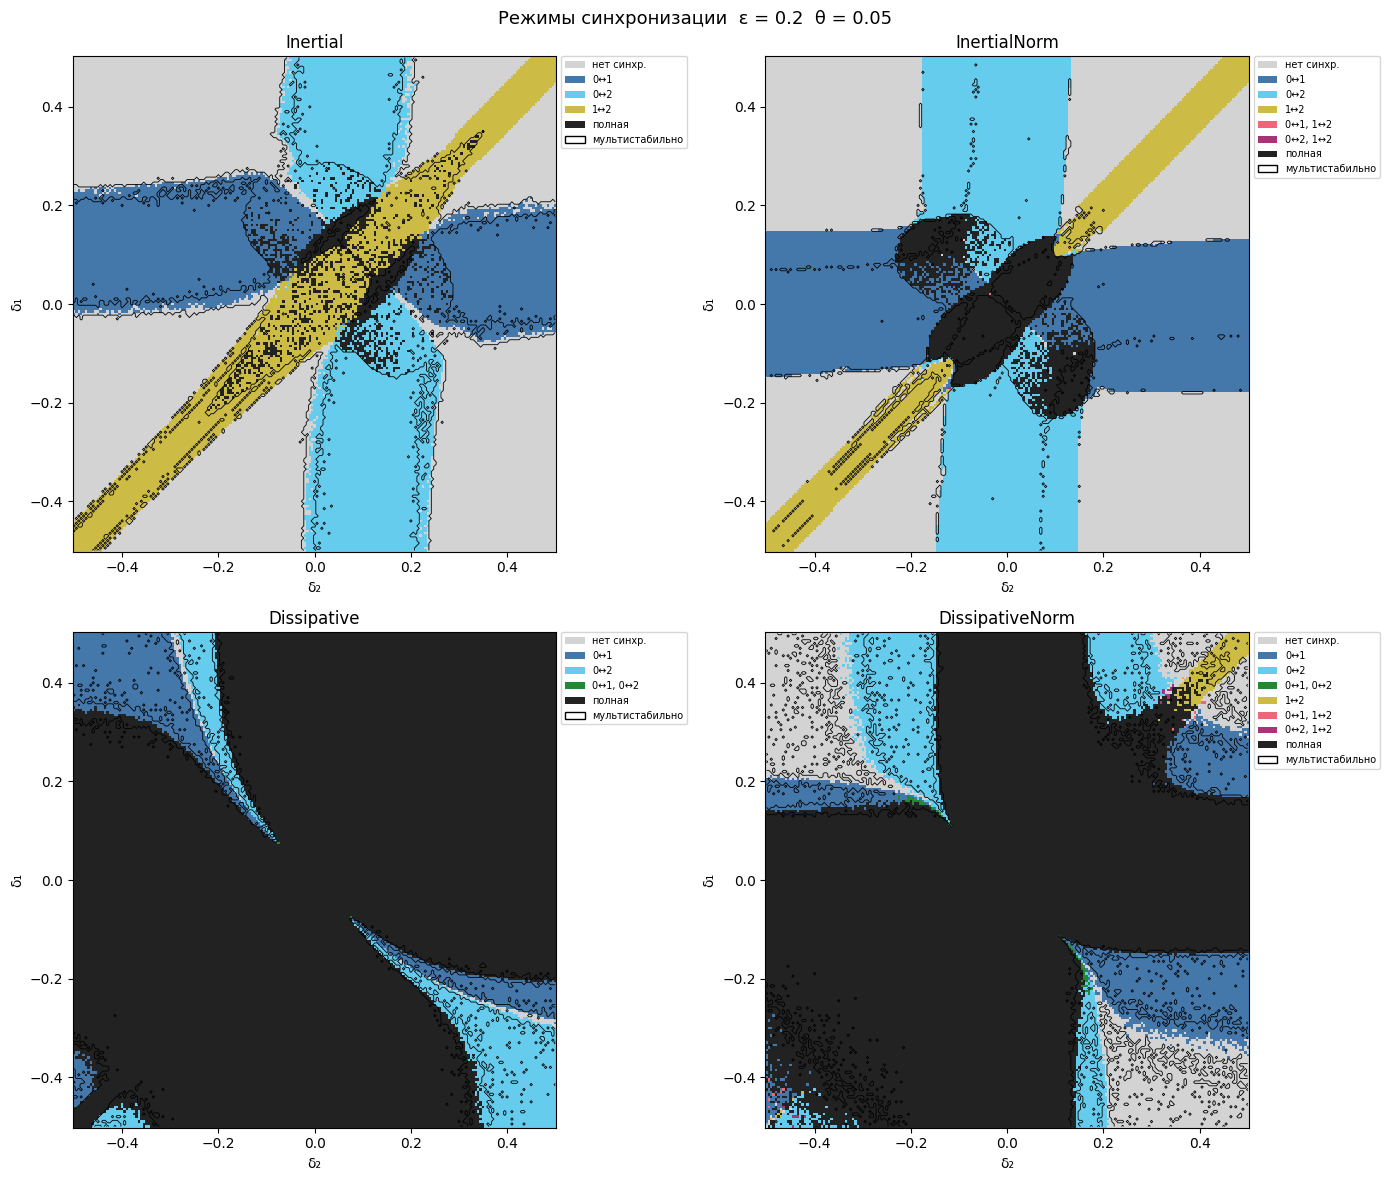

In [22]:
for eps in epsilons:
    plot_regime_maps(eps)

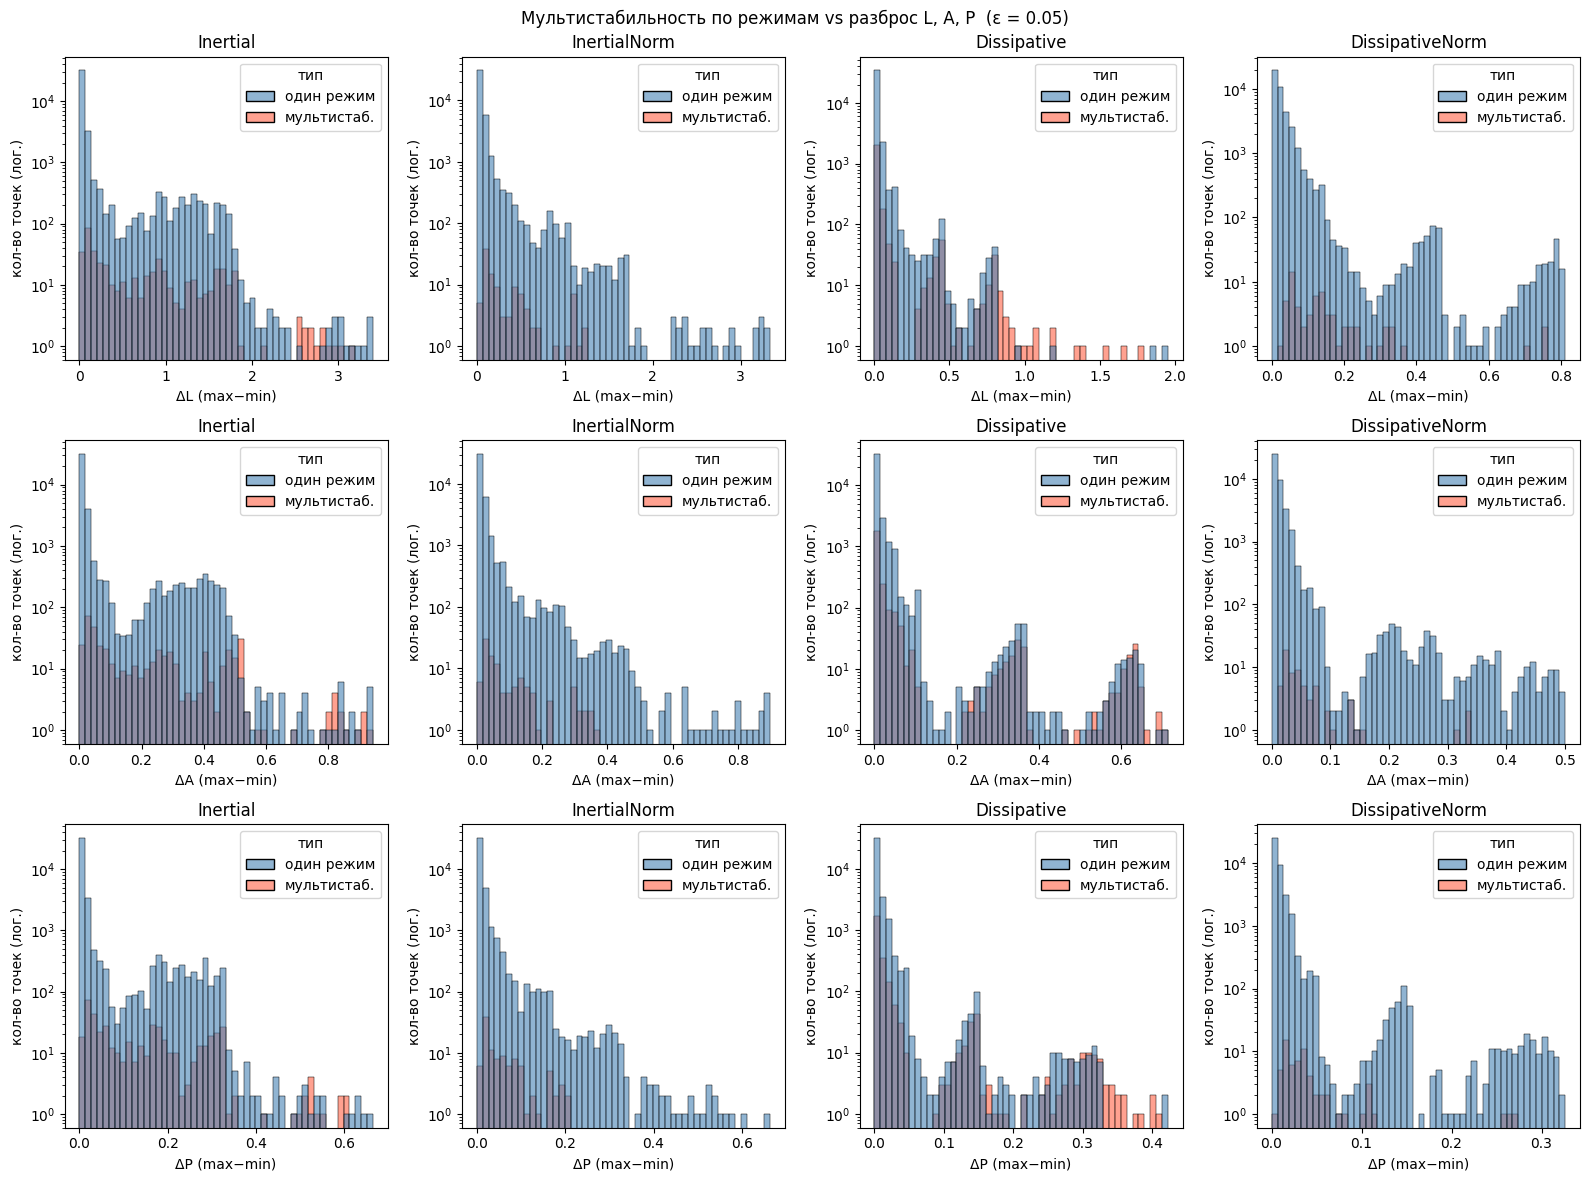

In [23]:
sub = df[df['eps'] == eps_val].copy()
sub['code'] = sub.apply(lambda r: sync_code(r, 0.05), axis=1)

agg = sub.groupby(['delta1', 'delta2', 'coupling_type']).agg(
    multi_regime=('code', lambda x: x.nunique() > 1),
    l_spread=('L', lambda x: x.max() - x.min()),
    a_spread=('A', lambda x: x.max() - x.min()),
    p_spread=('P', lambda x: x.max() - x.min()),
).reset_index()
agg['тип'] = agg['multi_regime'].map({True: 'мультистаб.', False: 'один режим'})

metrics = [('l_spread', 'ΔL (max−min)'), ('a_spread', 'ΔA (max−min)'), ('p_spread', 'ΔP (max−min)')]

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
fig.suptitle(f'Мультистабильность по режимам vs разброс L, A, P  (ε = {eps_val})')

for row_idx, (col_name, xlabel) in enumerate(metrics):
    for ct in range(4):
        data = agg[agg['coupling_type'] == ct]
        sns.histplot(data=data, x=col_name, hue='тип', bins=50, alpha=0.6,
                     ax=axes[row_idx, ct], element='bars',
                     palette={'один режим': 'steelblue', 'мультистаб.': 'tomato'})
        axes[row_idx, ct].set_yscale('log')
        axes[row_idx, ct].set_title(COUPLING_NAMES[ct])
        axes[row_idx, ct].set_xlabel(xlabel)
        axes[row_idx, ct].set_ylabel('кол-во точек (лог.)')

plt.tight_layout()
plt.show()

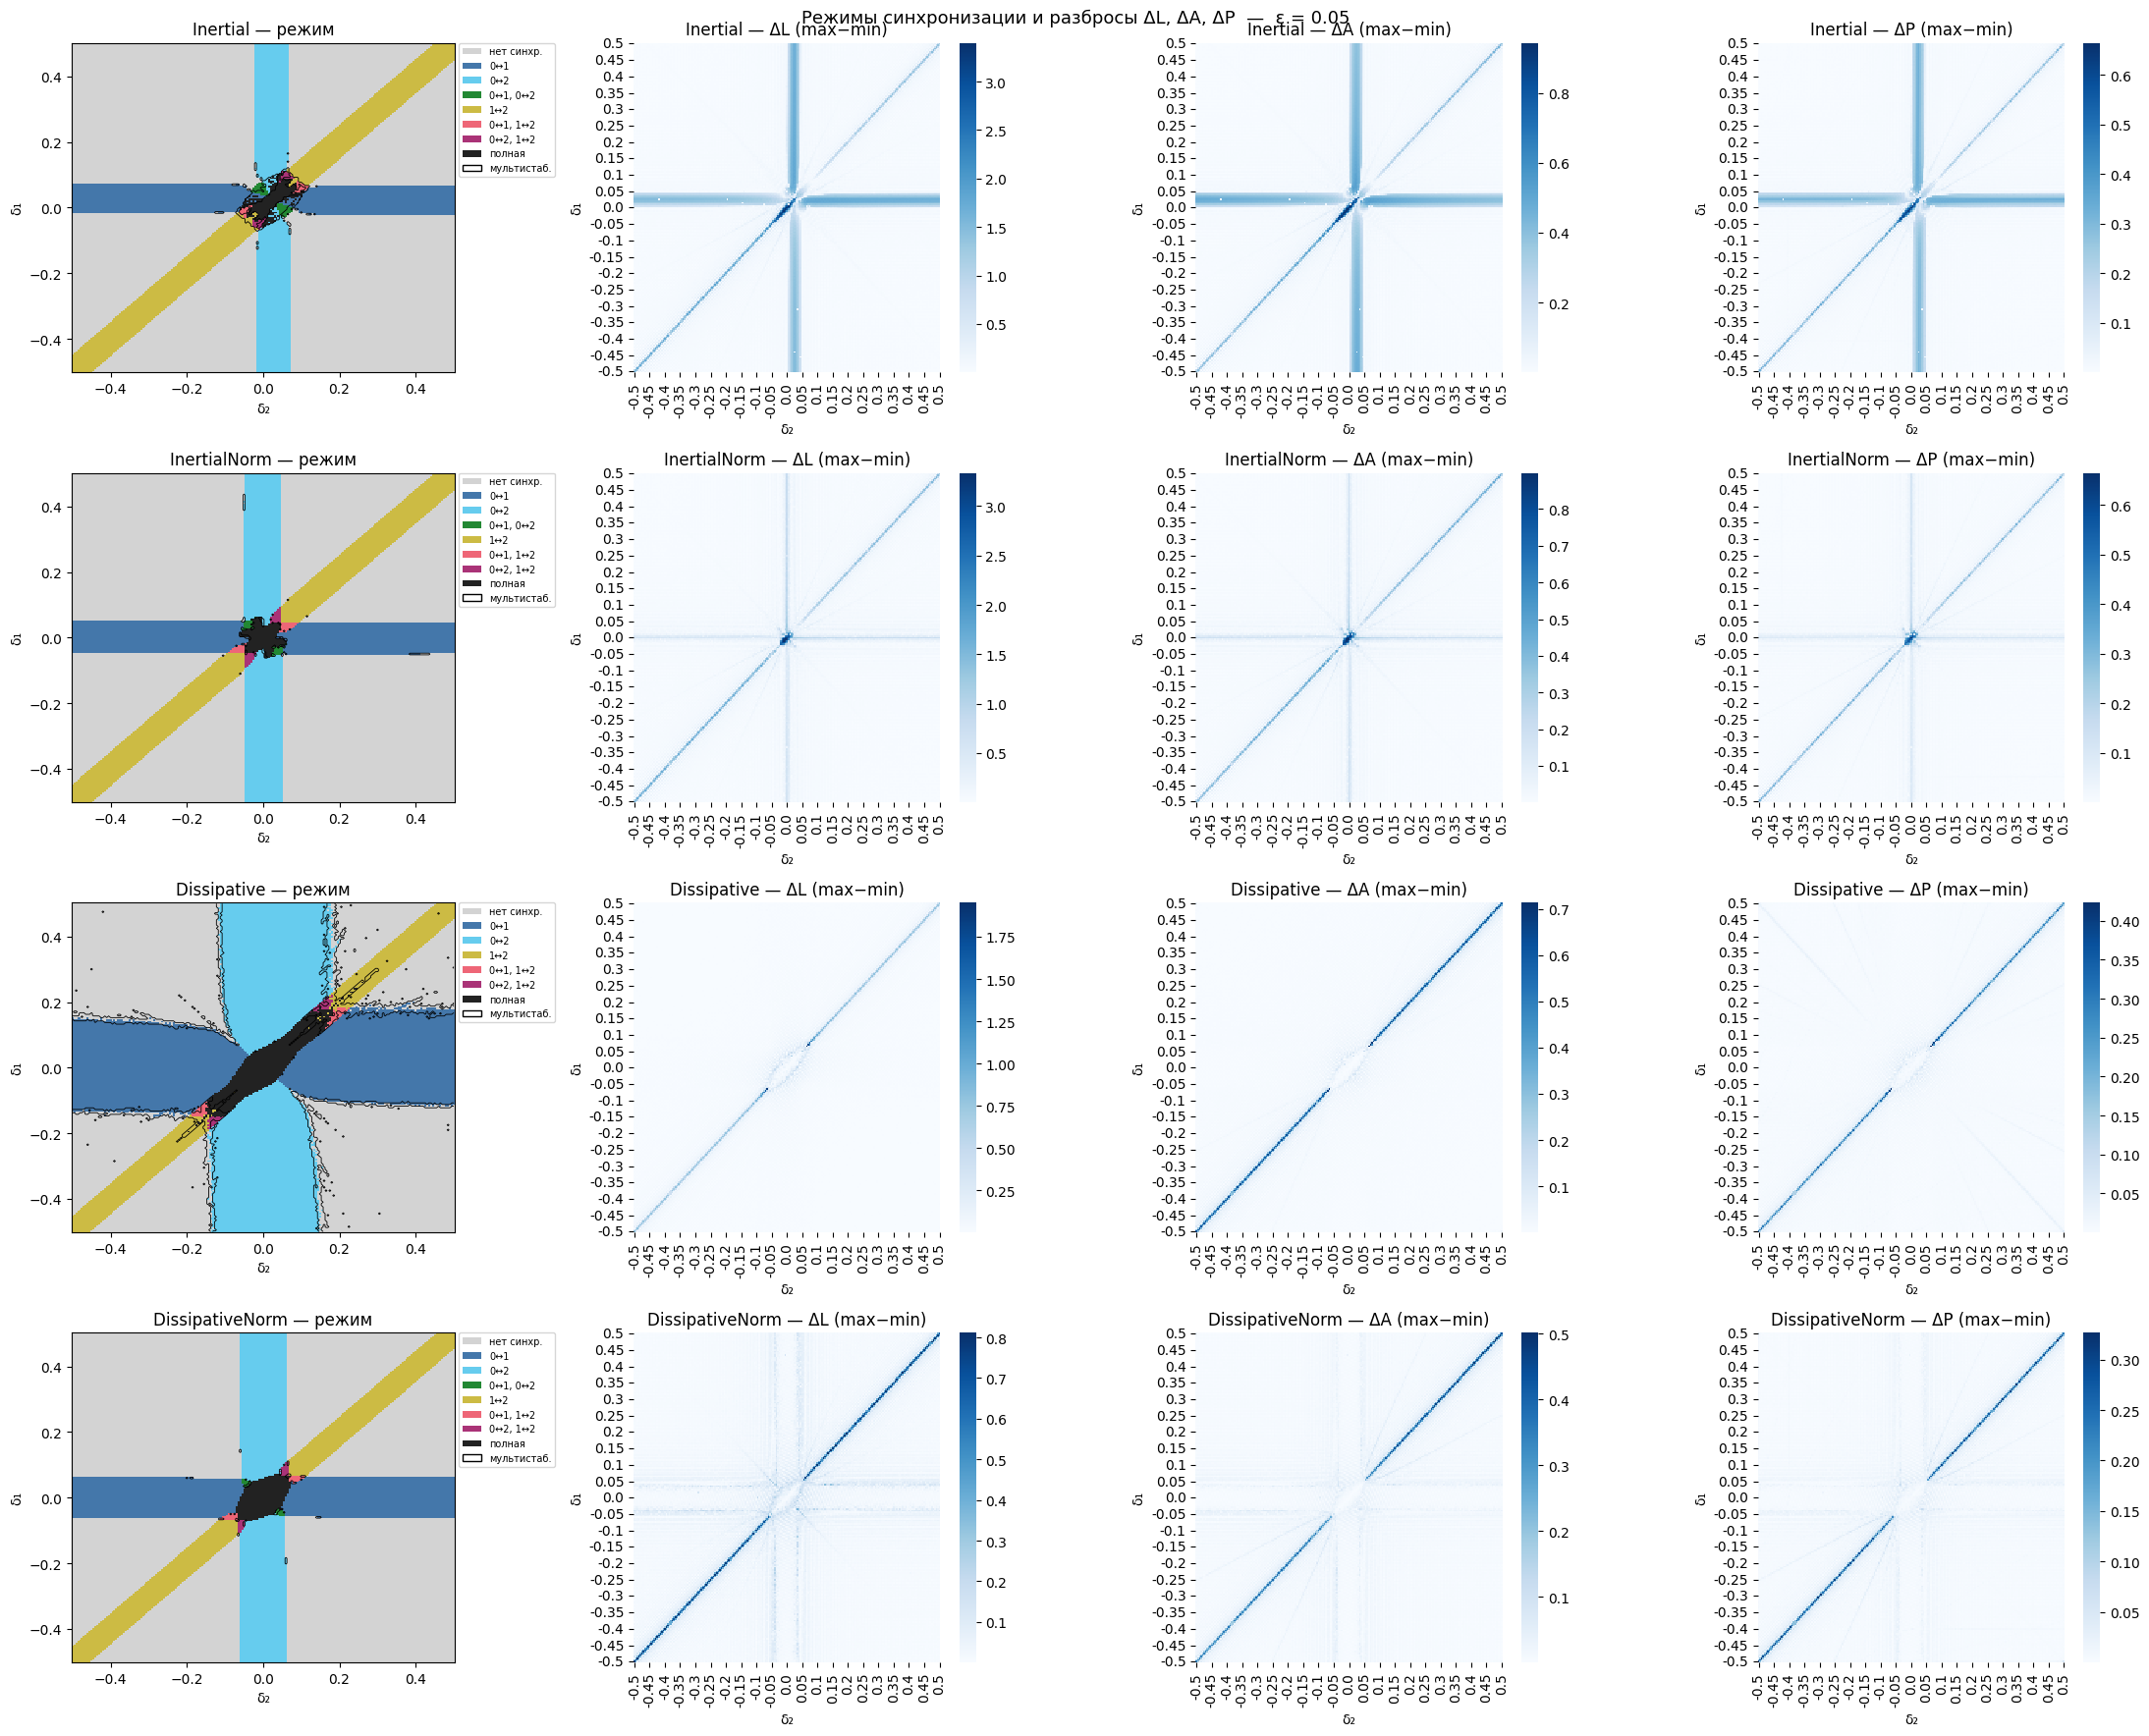

In [24]:
def plot_regime_vs_spreads(eps_val, theta=0.05):
    sub = df[df['eps'] == eps_val].copy()
    sub['code'] = sub.apply(lambda r: sync_code(r, theta), axis=1)

    agg = sub.groupby(['delta1', 'delta2', 'coupling_type']).agg(
        dominant_code=('code', lambda x: x.value_counts().idxmax()),
        l_spread=('L', lambda x: x.max() - x.min()),
        a_spread=('A', lambda x: x.max() - x.min()),
        p_spread=('P', lambda x: x.max() - x.min()),
        multi_regime=('code', lambda x: x.nunique() > 1),
    ).reset_index()

    cmap_reg = mcolors.ListedColormap(REGIME_COLORS)
    norm_reg = mcolors.BoundaryNorm(np.arange(-0.5, 8.5), ncolors=8)
    spreads = [('l_spread', 'ΔL'), ('a_spread', 'ΔA'), ('p_spread', 'ΔP')]

    fig, axes = plt.subplots(4, 4, figsize=(22, 18))
    fig.suptitle(f'Режимы синхронизации и разбросы ΔL, ΔA, ΔP  —  ε = {eps_val}', fontsize=13)

    for ct in range(4):
        data = agg[agg['coupling_type'] == ct]
        dom     = data.pivot(index='delta1', columns='delta2', values='dominant_code')
        mul_reg = data.pivot(index='delta1', columns='delta2', values='multi_regime')

        ax_reg = axes[ct, 0]
        ax_reg.pcolormesh(dom.columns, dom.index, dom.values,
                          cmap=cmap_reg, norm=norm_reg, shading='auto')
        draw_borders(ax_reg, mul_reg)
        ax_reg.set_title(f'{COUPLING_NAMES[ct]} — режим')
        ax_reg.set_xlabel('δ₂'); ax_reg.set_ylabel('δ₁')
        present = sorted(data['dominant_code'].unique())
        handles = [Patch(facecolor=REGIME_COLORS[c], label=REGIME_LABELS[c]) for c in present]
        handles.append(Patch(facecolor='white', edgecolor='black', label='мультистаб.'))
        ax_reg.legend(handles=handles, loc='upper left', bbox_to_anchor=(1.01, 1), borderaxespad=0, fontsize=7)

        for col_idx, (spread_col, spread_label) in enumerate(spreads, start=1):
            spread = data.pivot(index='delta1', columns='delta2', values=spread_col)
            ax = axes[ct, col_idx]
            sns.heatmap(spread.iloc[::-1], cmap='Blues', ax=ax,
                        xticklabels=10, yticklabels=10)
            ax.set_title(f'{COUPLING_NAMES[ct]} — {spread_label} (max−min)')
            ax.set_xlabel('δ₂'); ax.set_ylabel('δ₁')

    plt.tight_layout()
    plt.show()

plot_regime_vs_spreads(eps_val)

## Исследование $\Delta L$, $\Delta A$, $\Delta P$ как критериев мультистабильности

**1. Постановка вопроса.**
Проверялась гипотеза: можно ли использовать разброс когерентности
$\Delta L$ $\Delta A$ и $\Delta P$ по $n_{\text{ic}}$ начальным условиям
как индикатор мультистабильности — альтернативу критерию по разнообразию sync\_code.

**2. Построение гистограмм.**
Для $\varepsilon = 0.1$, по всем типам связи и всем точкам сетки $(\delta_1, \delta_2)$
вычислялись $\Delta L$, $\Delta A$, $\Delta P$ и флаг мультистабильности (истина, если по 10 НУ встречается $> 1$ значения sync\_code).
Построены гистограммы раздельно для моно- и мультирежимных точек (лог. шкала).
Распределения не разделились — гипотеза отвергнута для всех трёх метрик.

Для $\Delta L$ подтверждение выбраны два контрпримера (ниже).

### Поиск контрпримеров

In [25]:
## Верификация методологии

theta = 0.05
sub = df[df['eps'] == eps_val].copy()
sub['code'] = sub.apply(lambda r: sync_code(r, theta), axis=1)

agg = sub.groupby(['delta1', 'delta2', 'coupling_type']).agg(
    multi_regime=('code', lambda x: x.nunique() > 1),
    l_spread=('L', lambda x: x.max() - x.min()),
    a_spread=('A', lambda x: x.max() - x.min()),
    p_spread=('P', lambda x: x.max() - x.min()),
    codes=('code', list),
    L_vals=('L', list),
    A_vals=('A', list),
    P_vals=('P', list),
).reset_index()

ct = 0  # Inertial
data = agg[agg['coupling_type'] == ct]

# 1. Пример точки с мультистабильностью и малым l_spread
multi_small = data[data['multi_regime'] & (data['l_spread'] < 0.1)].head(3)
print("=== Мультистабильные точки с малым ΔL (<0.1) ===")
for _, row in multi_small.iterrows():
    print(f"  δ1={row.delta1:.2f} δ2={row.delta2:.2f}  ΔL={row.l_spread:.4f}  ΔA={row.a_spread:.4f}  ΔP={row.p_spread:.4f}")
    print(f"  коды по 10 НУ: {row.codes}")
    print(f"  L: {[round(x,3) for x in row.L_vals]}")
    print(f"  A: {[round(x,3) for x in row.A_vals]}")
    print(f"  P: {[round(x,3) for x in row.P_vals]}")

print()

# 2. Пример точки с одним режимом и большим l_spread
mono_large = data[~data['multi_regime'] & (data['l_spread'] > 0.5)].head(3)
print("=== Одно-режимные точки с большим ΔL (>0.5) ===")
for _, row in mono_large.iterrows():
    print(f"  δ1={row.delta1:.2f} δ2={row.delta2:.2f}  ΔL={row.l_spread:.4f}  ΔA={row.a_spread:.4f}  ΔP={row.p_spread:.4f}")
    print(f"  коды по 10 НУ: {row.codes}")
    print(f"  L: {[round(x,3) for x in row.L_vals]}")
    print(f"  A: {[round(x,3) for x in row.A_vals]}")
    print(f"  P: {[round(x,3) for x in row.P_vals]}")

print()

=== Мультистабильные точки с малым ΔL (<0.1) ===
  δ1=-0.12 δ2=-0.01  ΔL=0.0926  ΔA=0.0283  ΔP=0.0209
  коды по 10 НУ: [2, 0, 2, 0, 0, 0, 2, 0, 2, 0]
  L: [1.186, 1.124, 1.113, 1.108, 1.192, 1.099, 1.187, 1.133, 1.149, 1.12]
  A: [0.364, 0.345, 0.341, 0.34, 0.367, 0.338, 0.364, 0.348, 0.354, 0.34]
  P: [0.52, 0.506, 0.504, 0.503, 0.52, 0.501, 0.519, 0.508, 0.512, 0.5]
  δ1=-0.12 δ2=-0.01  ΔL=0.0917  ΔA=0.0314  ΔP=0.0269
  коды по 10 НУ: [0, 2, 2, 2, 0, 0, 2, 2, 0, 2]
  L: [1.136, 1.147, 1.176, 1.137, 1.156, 1.096, 1.131, 1.187, 1.131, 1.121]
  A: [0.352, 0.357, 0.366, 0.343, 0.351, 0.334, 0.35, 0.364, 0.352, 0.349]
  P: [0.51, 0.518, 0.523, 0.501, 0.503, 0.497, 0.511, 0.519, 0.512, 0.511]
  δ1=-0.11 δ2=-0.01  ΔL=0.0494  ΔA=0.0159  ΔP=0.0130
  коды по 10 НУ: [2, 0, 2, 2, 0, 2, 2, 2, 2, 2]
  L: [1.17, 1.138, 1.183, 1.173, 1.135, 1.185, 1.179, 1.162, 1.169, 1.156]
  A: [0.359, 0.348, 0.363, 0.359, 0.348, 0.363, 0.36, 0.357, 0.358, 0.353]
  P: [0.515, 0.506, 0.518, 0.515, 0.505, 0.518, 0.5

### Проверка точки с маленьким $\Delta L$, но мультистабильностью

In [26]:
# Проверка гипотезы: осциллятор 1 доминирует в сумме
# Берём точку δ1=-0.20, δ2=0.12, смотрим начальные условия по режимам

point = df[
    (df['eps'] == epsilons[2]) &
    (df['coupling_type'] == 0) &
    (np.isclose(df['delta1'], -0.20, atol=0.01)) &
    (np.isclose(df['delta2'],  0.12, atol=0.01))
].copy()
point['code'] = point.apply(lambda r: sync_code(r, 0.05), axis=1)

print("δ1=-0.20, δ2=0.12, Inertial — все 10 прогонов:")
print(f"{'код':>5}  {'L':>6}  {'x0':>7}  {'y0':>7}  {'x1':>7}  {'y1':>7}  {'x2':>7}  {'y2':>7}")
for _, r in point.iterrows():
    print(f"{int(r.code):>5}  {r.L:>6.3f}  {r.x0:>7.3f}  {r.y0:>7.3f}  {r.x1:>7.3f}  {r.y1:>7.3f}  {r.x2:>7.3f}  {r.y2:>7.3f}")

δ1=-0.20, δ2=0.12, Inertial — все 10 прогонов:
  код       L       x0       y0       x1       y1       x2       y2
    0   1.157   -0.944    1.542    1.484    2.608    0.621    1.247
    0   1.150    0.093    1.570   -2.680    0.314    2.351    1.495
    0   1.147    0.257    1.401    0.638    0.799   -1.067    1.301
    0   1.154   -2.078    2.861   -0.060    0.046    1.159    2.454
    0   1.160    2.254   -2.118    2.160   -2.686    0.889    1.477
    0   1.141   -2.530   -0.876    2.588   -0.895    2.987    0.988
    0   1.157   -0.205   -0.976   -0.777   -0.584    0.594   -2.439
    0   1.121    0.276    1.757    0.403   -0.335   -2.155   -0.513
    0   1.163   -1.008   -2.471    0.371    1.840   -2.020    0.604
    0   1.159    0.510    1.910    1.536    1.396    0.076    2.431
    0   1.146   -1.888    0.999    0.087   -1.990    0.385   -2.192
    0   1.144    1.597   -2.652    2.194    1.604    2.107   -2.265
    0   1.140   -2.778   -0.331    2.830   -2.858   -0.041   -1.824
 

### Проверка точки с высоким $\Delta L$, но однорежимностью

In [27]:
# δ1=-0.50, δ2=-0.50: один режим (код=4), но огромный разброс L
point2 = df[
    (df['eps'] == epsilons[2]) &
    (df['coupling_type'] == 0) &
    (np.isclose(df['delta1'], -0.50, atol=0.01)) &
    (np.isclose(df['delta2'], -0.50, atol=0.01))
].copy()
point2['code'] = point2.apply(lambda r: sync_code(r, 0.05), axis=1)

print("δ1=-0.50, δ2=-0.50, Inertial — все 10 прогонов:")
print(f"{'код':>5}  {'L':>6}  {'x0':>7}  {'y0':>7}  {'x1':>7}  {'y1':>7}  {'x2':>7}  {'y2':>7}")
for _, r in point2.iterrows():
    print(f"{int(r.code):>5}  {r.L:>6.3f}  {r.x0:>7.3f}  {r.y0:>7.3f}  {r.x1:>7.3f}  {r.y1:>7.3f}  {r.x2:>7.3f}  {r.y2:>7.3f}")

δ1=-0.50, δ2=-0.50, Inertial — все 10 прогонов:
  код       L       x0       y0       x1       y1       x2       y2
    4   0.340    2.857    0.512   -2.620    2.443   -1.260    0.766
    4   2.050   -2.062    2.941    1.335   -1.567   -1.579   -1.246
    4   0.315    0.347    1.197    0.818    1.753    1.185   -1.646
    4   2.018   -2.886    0.939    0.771    1.631   -2.901    2.440
    4   1.341   -0.471   -2.478   -1.160   -1.273    0.754   -2.569
    4   0.332    2.683   -2.432    0.563    1.767    0.442   -2.165
    4   0.390   -1.413   -0.846   -2.813    0.674   -0.198   -1.386
    4   1.283    0.602   -2.497   -2.780   -2.964    1.557   -2.544
    4   0.317   -1.926    0.580   -0.856    2.285   -2.194    0.474
    4   1.373   -1.781    1.186    0.349    0.747   -1.435    1.849
    4   0.622    2.438   -0.859   -2.122    1.303   -2.906   -0.940
    4   1.047   -1.758   -2.847    0.453    0.157    1.068   -2.534
    4   1.452    1.931    1.615    1.668   -2.749    1.161   -0.202


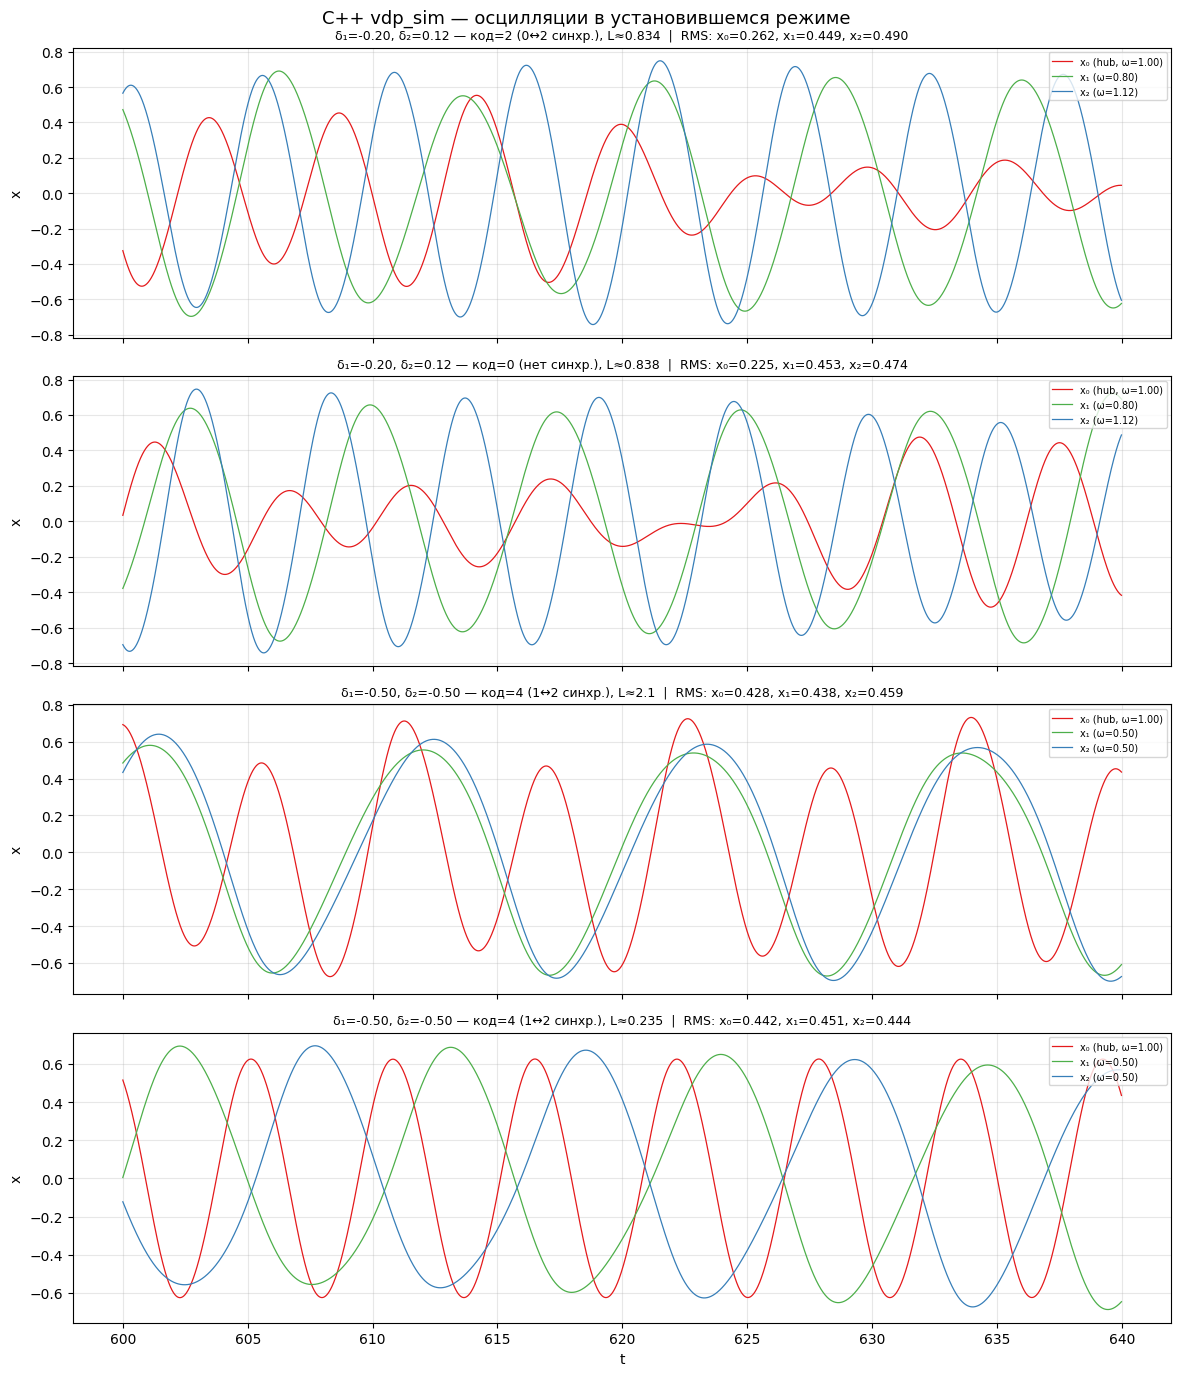

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

t_trans = 600.0
plot_window = 40.0

runs = [
    {
        'title': 'δ₁=-0.20, δ₂=0.12 — код=2 (0↔2 синхр.), L≈0.834',
        'path': '../simulation/demo/small_l_code2.csv',
        'labels': ['x₀ (hub, ω=1.00)', 'x₁ (ω=0.80)', 'x₂ (ω=1.12)'],
    },
    {
        'title': 'δ₁=-0.20, δ₂=0.12 — код=0 (нет синхр.), L≈0.838',
        'path': '../simulation/demo/small_l_code0.csv',
        'labels': ['x₀ (hub, ω=1.00)', 'x₁ (ω=0.80)', 'x₂ (ω=1.12)'],
    },
    {
        'title': 'δ₁=-0.50, δ₂=-0.50 — код=4 (1↔2 синхр.), L≈2.1',
        'path': '../simulation/demo/large_dl_high_l.csv',
        'labels': ['x₀ (hub, ω=1.00)', 'x₁ (ω=0.50)', 'x₂ (ω=0.50)'],
    },
    {
        'title': 'δ₁=-0.50, δ₂=-0.50 — код=4 (1↔2 синхр.), L≈0.235',
        'path': '../simulation/demo/large_dl_low_l.csv',
        'labels': ['x₀ (hub, ω=1.00)', 'x₁ (ω=0.50)', 'x₂ (ω=0.50)'],
    },
]

colors = ['#e41a1c', '#4daf4a', '#377eb8']

fig, axes = plt.subplots(4, 1, figsize=(12, 14), sharex=True)
fig.suptitle('C++ vdp_sim — осцилляции в установившемся режиме', fontsize=13)

for ax, run in zip(axes, runs):
    df_run = pd.read_csv(run['path'])
    steady = df_run[(df_run['t'] >= t_trans) & (df_run['t'] < t_trans + plot_window)]

    for col, c, lbl in zip(['x0', 'x1', 'x2'], colors, run['labels']):
        ax.plot(steady['t'], steady[col], color=c, lw=0.9, label=lbl)

    rms = [np.sqrt((steady[f'x{i}']**2).mean()) for i in range(3)]
    ax.set_title(f"{run['title']}  |  RMS: x₀={rms[0]:.3f}, x₁={rms[1]:.3f}, x₂={rms[2]:.3f}",
                 fontsize=9)
    ax.set_ylabel('x')
    ax.legend(fontsize=7, loc='upper right')
    ax.grid(alpha=0.3)

axes[-1].set_xlabel('t')
plt.tight_layout()
plt.show()